# Assignment 2 2AMM10 2025-2026

## Group: Transistor
### Member 1: Clara Montemurro
### Member 2: Mirco Terenzi
### Member 3: Tommaso Zanotti

## Introduction
Hannah Wolffson, a world-renowned Formula 1 chief engineer known for her expertise in high performance systems and data-driven engineering, has been approached by a leading German automotive manufacturer to guide the transition toward next-generation autonomous vehicles.
While her background is rooted in motorsport, she has become a strong advocate for integrating modern AI methods into safety-critical systems.
Recognizing that these challenges are not only technological but also conceptual, she launches an initiative to recruit Europe’s most talented MSc students (that would be you :). Your objective is to assist her in identifying suitable learning architectures capable of capturing the visual and geometric complexities encountered in autonomous driving systems.

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytorch_lightning as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.nn import global_mean_pool
from torchmetrics.classification import (
    BinaryPrecision,
    BinaryRecall,
    MulticlassPrecision,
    MulticlassRecall,
)
from torchmetrics.functional.classification import (
    multiclass_precision,
    multiclass_recall,
)
from torchvision.models import ViT_B_16_Weights, vit_b_16
from torchvision.transforms import Compose, Resize, ToTensor
from torchvision.transforms import functional as TF

## Global Variables ##
pl.seed_everything(42)
DATA_DIR = "./data"
# Path to the drowsy dataset
DROWSY_DATASET_DIR = Path(DATA_DIR, "drowsy_graph_dataset")
# Path to the object classification dataset
OBJ_CLS_DATASET_DIR = Path(DATA_DIR, "bdd8cls_balanced_300_30")

FAST_DEV_RUN = False

DEVICE = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else (
        torch.device("mps")
        if torch.backends.mps.is_available()
        else torch.device("cpu")
    )
)

Seed set to 42


## Task 1

An important component of autonomous driving is detecting when a driver is becoming drowsy or about to fall asleep. However, relying solely on standard RGB cameras can be problematic, particularly under low-light or nighttime driving conditions, where poor illumination may
significantly reduce image quality and reliability.
Our customer uses a sophisticated driver-monitoring system that combines infrared and depth sensors with geometric facial-tracking software to construct upper-face mesh graphs regardless of lighting conditions.  
Your objective is to design and train a neural-network architecture, which leverages the dataset symmetries, capable of detecting whether a driver is awake or drowsy. The model must be implemented from scratch.

### Dataset
Due to budget restrictions and fierce market competition, Professor Wolffson is eager for efficient
and rapid prototyping. You are therefore given the following preprocessed datasets, each corresponding to a different perception task:
A graph dataset associated with driver drowsiness detection.
It consists of 400 training and 100 test upper-face mesh graphs. Each graph corresponds
to a driver who is either awake or drowsy.

In [2]:
class DrowsyFaceGraphDataset(Dataset):
    def __init__(self, root, split="train"):
        self.root = Path(root)
        self.split = split

        data_path = self.root / f"{split}.pt"
        class_to_id_path = self.root / "class_to_id.json"
        id_to_class_path = self.root / "id_to_class.json"

        if not data_path.exists():
            raise FileNotFoundError(f"Could not find {data_path}")

        self.graphs = torch.load(data_path, weights_only=False)

        with open(class_to_id_path, "r") as f:
            self.class_to_id = json.load(f)

        with open(id_to_class_path, "r") as f:
            self.id_to_class = json.load(f)

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        return self.graphs[idx]


train_drowy_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="train")
test_drowy_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="test")
class_to_id: dict = train_drowy_dataset.class_to_id
id_to_class: dict = train_drowy_dataset.id_to_class

##

<Axes: >

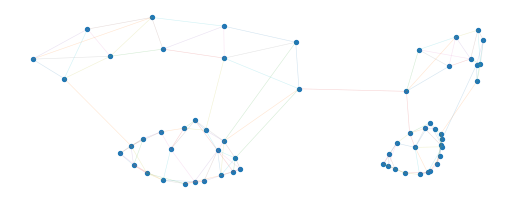

In [3]:
# Visualization helper
def plot_face_graph(
    graph, ax=None, title=None, node_size=8, edge_alpha=0.20, edge_width=0.4
):
    """Plot one face graph using its 2D normalized landmark coordinates."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))

    coords = graph.x.cpu().numpy()  # Nodes of the Graph
    edge_index = graph.edge_index.cpu().numpy()  # Edges of the Graph

    xy = coords[:, :2]

    seen = set()
    for i, j in edge_index.T:
        a, b = int(i), int(j)
        key = tuple(sorted((a, b)))
        if key in seen:
            continue
        seen.add(key)
        ax.plot(
            [xy[a, 0], xy[b, 0]],
            [xy[a, 1], xy[b, 1]],
            linewidth=edge_width,
            alpha=edge_alpha,
        )

    ax.scatter(xy[:, 0], xy[:, 1], s=node_size)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.axis("off")

    if title is not None:
        ax.set_title(title)

    return ax


fig, ax = plt.subplots()
idx = random.randint(0, len(train_drowy_dataset) - 1)
graph = train_drowy_dataset[idx]
x, y = graph.x, graph.y
plot_face_graph(graph, ax)

# Understanding the samples
# 1) graph.x: (Num_nodes, 3) matrix. The coordinates (x1,x2,x3) of the facial landmarks, normalized to [-1,1]. Those are the node features of the graph.
# 2) graph.edge_index: (2, Num_edges) matrix. The edges of the graph, where each column (i,j) represents an edge from node i to node j.
# 3) graph.y: The label of the graph, where 0 means "alert" and 1 means "drowsy". This is the target variable we want to predict.
# 4) You can safely ignore the other 2 attributes of the graph (source_index and eye_openness) for this assignment.
# For completeness, eye_openness is a score in [0,1] that indicates how open the eyes are, and source_index is an index corresponding to the sample index with respect to the original dataset before graph construction.

In [4]:
class DrowyDataModule(pl.LightningDataModule):
    def __init__(self, train_dataset, test_dataset, batch_size=32):
        super().__init__()
        self.train_dataset = train_dataset
        self.test_dataset = test_dataset
        self.batch_size = batch_size

    def train_dataloader(self):
        return GeoDataLoader(
            self.train_dataset, batch_size=self.batch_size, shuffle=True
        )

    def val_dataloader(self):
        return GeoDataLoader(
            self.test_dataset, batch_size=self.batch_size, shuffle=False
        )

    def test_dataloader(self):
        return GeoDataLoader(
            self.test_dataset, batch_size=self.batch_size, shuffle=False
        )


data_module = DrowyDataModule(train_drowy_dataset, test_drowy_dataset)

### Implementation

In [5]:
class MpLayer(nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()

        self.transfer_function_net = nn.Sequential(
            nn.Linear(2 * hidden_channels, hidden_channels),
            nn.ReLU(),
        )

        self.node_update_net = nn.Sequential(
            nn.Linear(2 * hidden_channels, hidden_channels),
            nn.ReLU(),
        )

    def forward(self, input):
        x, edge_index = input
        source, dest = edge_index

        messages = self.transfer_function_net(torch.cat([x[source], x[dest]], dim=-1))

        agg = torch.zeros_like(x)
        agg.scatter_add_(
            dim=0, index=dest.unsqueeze(-1).expand(-1, x.size(1)), src=messages
        )

        x = self.node_update_net(torch.cat([x, agg], dim=1))

        return x, edge_index


class Task1MpGNN(nn.Module):
    def __init__(
        self,
        in_channels=3,
        hidden_channels=32,
        num_classes=2,
        num_layers=3,
    ):
        super().__init__()

        self.to_emb = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            nn.ReLU(),
        )

        self.forward_net = nn.Sequential(
            *[MpLayer(hidden_channels) for _ in range(num_layers)]
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.BatchNorm1d(hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, num_classes),
        )

    def forward(self, data):
        x, edge_index, batch = (data.x, data.edge_index, data.batch)
        x = self.to_emb(x)
        x, _ = self.forward_net((x, edge_index))
        x = global_mean_pool(x, batch)
        return self.classifier(x)


class Task1LitModule(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.model = Task1MpGNN()
        self.loss_fn = nn.CrossEntropyLoss()
        self.history = {"train_loss": [], "eval_loss": []}

        self.test_precision = BinaryPrecision()
        self.test_recall = BinaryRecall()

    def on_train_start(self):
        self.history = {"train_loss": [], "eval_loss": []}

    def forward(self, batch):
        return self.model(batch)

    def predict_step(self, batch, batch_idx, dataloader_idx=0):
        logits = self(batch)
        return logits.argmax(dim=1)

    def training_step(self, batch, batch_idx):
        logits = self(batch)
        loss = self.loss_fn(logits, batch.y)
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        logits = self(batch)
        loss = self.loss_fn(logits, batch.y)
        self.log("eval_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        avg_loss = self.trainer.callback_metrics["train_loss_epoch"].item()
        self.history["train_loss"].append(avg_loss)

    def on_validation_epoch_end(self):
        avg_loss = self.trainer.callback_metrics["eval_loss_epoch"].item()
        self.history["eval_loss"].append(avg_loss)

    def test_step(self, batch, batch_idx):
        predictions = self.predict_step(batch, batch_idx)

        self.test_precision(predictions, batch.y)
        self.test_recall(predictions, batch.y)

        self.log("test_precision", self.test_precision, on_step=False, on_epoch=True)
        self.log("test_recall", self.test_recall, on_step=False, on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters())

### Training

GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name           | Type             | Params | Mode  | FLOPs
--------------------------------------------------------------------
0 | model          | Task1MpGNN       | 13.8 K | train | 0    
1 | loss_fn        | CrossEntropyLoss | 0      | train | 0    
2 | test_precision | BinaryPrecision  | 0      | train | 0    
3 | test_recall    | BinaryRecall     | 0      | train | 0    
--------------------------------------------------------------------
13.8 K    Trainable params
0         Non-trainable params
13.8 K    Total params
0.055     Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode
0         Total Flops


`Trainer.fit` stopped: `max_epochs=50` reached.


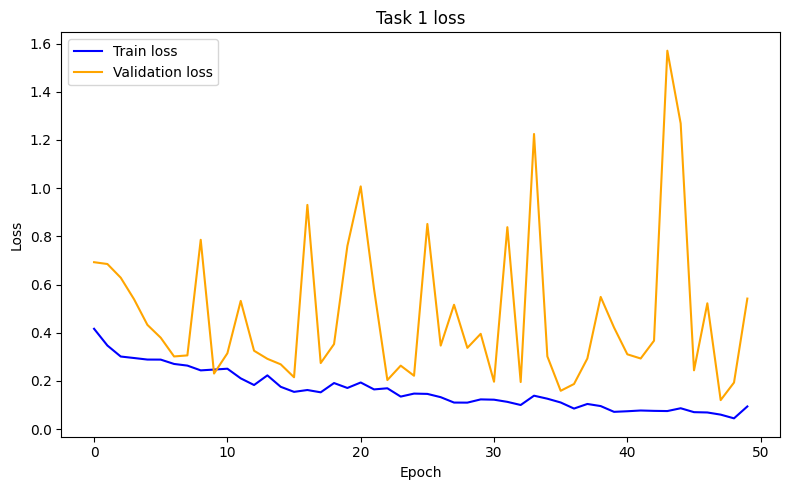

In [6]:
task1_lit_module = Task1LitModule()

checkpoint_callback = pl.callbacks.ModelCheckpoint(
    monitor="eval_loss_epoch",
    mode="min",
    save_top_k=1,
    filename="best-checkpoint",
)

trainer = pl.Trainer(
    max_epochs=50,
    accelerator="auto",
    callbacks=[checkpoint_callback],
    fast_dev_run=FAST_DEV_RUN,
)
trainer.fit(task1_lit_module, datamodule=data_module)

# log and visualize the training and test losses throughout training.
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(task1_lit_module.history["train_loss"], label="Train loss", color="blue")
ax.plot(task1_lit_module.history["eval_loss"], label="Validation loss", color="orange")
ax.set_title("Task 1 loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.tight_layout()
plt.show()

### Evaluation
In safety-critical applications, selecting appropriate evaluation metrics is equally, if not more, important than selecting the architecture itself. In this setting, failing to detect a drowsy driver may prevent the vehicle from triggering an alarm or safety intervention, potentially leading to an accident. Compute:
- a metric of the fraction of truly drowsy drivers that are predicted as drowsy by the model,
- and a metric of the fraction of drivers predicted as drowsy by the model that are truly drowsy.

Then evaluate your trained model on the provided test set and visualize the resulting metrics in a single figure.

As a baseline requirement, your model must achieve a score of at least 0.6 on both evaluation metrics on the test set.

Restoring states from the checkpoint path at lightning_logs/version_162/checkpoints/best-checkpoint.ckpt
Loaded model weights from the checkpoint at lightning_logs/version_162/checkpoints/best-checkpoint.ckpt


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     test_precision         0.9591836929321289
       test_recall          0.9399999976158142
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


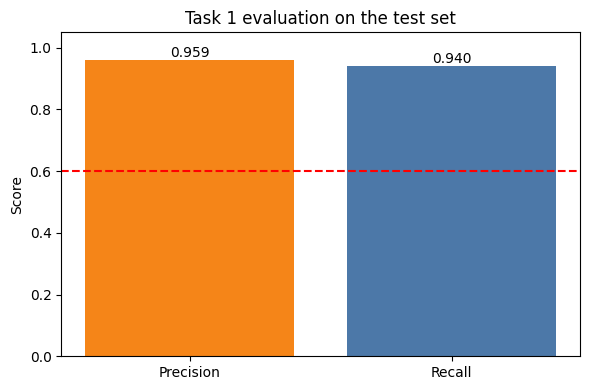

In [7]:
output_metrics = trainer.test(
    model=task1_lit_module, datamodule=data_module, ckpt_path="best"
)

precision = output_metrics[0]["test_precision"]
recall = output_metrics[0]["test_recall"]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Precision", "Recall"], [precision, recall], color=["#f58518", "#4c78a8"])
ax.axhline(y=0.6, color="red", linestyle="--", linewidth=1.5, label="Baseline (0.6)")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Task 1 evaluation on the test set")
ax.bar_label(ax.containers[0], fmt="%.3f")
plt.tight_layout()
plt.show()

## Task 2

### Dataset
A dataset associated with multi-class object classification. It consists of cropped object regions extracted from BDD100K1. Each sample contains a single object belonging to one of eight classes. For each class, 300 training samples and 30 test samples are provided.  
BDD100K is a large-scale driving dataset containing annotations for multiple autonomous-driving perception
tasks, including object detection, lane marking, drivable-area segmentation, and scene understanding.

In [20]:
class _BaseImageClassificationDataset(Dataset):
    """
    Base dataset for image classification datasets stored as:

        dataset_dir/
            class_to_id.json
            id_to_class.json
            train/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
            test/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
    """

    def __init__(
        self,
        dataset_dir,
        split="train",
        img_transform=None,
    ):
        super().__init__()
        self.dataset_dir = Path(dataset_dir)
        self.split = split
        self.img_transform = img_transform

        if self.split not in {"train", "test"}:
            raise ValueError(f"split must be 'train' or 'test', got: {self.split}")

        self.split_dir = self.dataset_dir / self.split
        self.labels_path = self.split_dir / "labels.csv"
        self.class_to_id_path = self.dataset_dir / "class_to_id.json"
        self.id_to_class_path = self.dataset_dir / "id_to_class.json"

        if not self.dataset_dir.exists():
            raise FileNotFoundError(f"Dataset directory not found: {self.dataset_dir}")
        if not self.split_dir.exists():
            raise FileNotFoundError(f"Split directory not found: {self.split_dir}")
        if not self.labels_path.exists():
            raise FileNotFoundError(f"labels.csv not found: {self.labels_path}")
        if not self.class_to_id_path.exists():
            raise FileNotFoundError(
                f"class_to_id.json not found: {self.class_to_id_path}"
            )
        if not self.id_to_class_path.exists():
            raise FileNotFoundError(
                f"id_to_class.json not found: {self.id_to_class_path}"
            )

        with open(self.class_to_id_path, "r") as fp:
            self.class_to_id = json.load(fp)

        with open(self.id_to_class_path, "r") as fp:
            self.id_to_class = json.load(fp)

        # Normalize keys for convenience
        self.id_to_class = {int(k): v for k, v in self.id_to_class.items()}
        self.num_classes = len(self.class_to_id)
        self.classes = [self.id_to_class[i] for i in range(self.num_classes)]

        with open(self.labels_path, mode="r") as f:
            self.labels = [int(line) for line in f if line.strip()]

        self.img_paths = sorted(
            [
                p
                for p in self.split_dir.iterdir()
                if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
            ],
            key=lambda p: p.name,
        )

        if len(self.img_paths) != len(self.labels):
            raise ValueError(
                f"Mismatch between number of images ({len(self.img_paths)}) and "
                f"labels ({len(self.labels)}) in split '{self.split}'."
            )

    def __len__(self):
        return len(self.labels)

    def _load_image(self, img_path):
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.img_transform is not None:
                img = self.img_transform(img)
            return img

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = self._load_image(img_path)
        label = self.labels[idx]

        return image, label


class BDDObjectClassificationDataset(_BaseImageClassificationDataset):
    """
    Dataset for the cropped-object classification dataset.

    Returns:
        image, label
    or:
        image, label, metadata   (if return_metadata=True)

    Notes:
        - img_transform defaults to None.
        - The user is responsible for resizing / tensor conversion.
    """

    pass


class PatchShuffle:
    def __init__(self, patch_size=8):
        self.p = patch_size

    def __call__(self, img):
        # Input: [C, H, W]
        c, h, w = img.shape
        p = self.p

        # 1. Unfold image into patches [C, H/p, W/p, p, p]
        patches = img.unfold(1, p, p).unfold(2, p, p)
        num_h = h // p
        num_w = w // p

        # 2. Reshape to [num_patches, C, p, p]
        patches = patches.contiguous().view(c, -1, p, p).permute(1, 0, 2, 3)

        # 3. Shuffle the patches along the first dimension
        idx = torch.randperm(patches.size(0))
        patches = patches[idx]

        # 4. Reshape back to original image dimensions
        # We need to rearrange from [num_h*num_w, C, p, p] back to [C, H, W]
        patches = patches.view(num_h, num_w, c, p, p).permute(2, 0, 3, 1, 4)
        shuffled_img = patches.contiguous().view(c, h, w)

        return shuffled_img

In [ ]:
class BottomRightSquarePad:
    """
    Makes the image square by adding black padding to the bottom or right.

    Why it's needed:
    To keep the original aspect ratio intact during the subsequent resizes and to
    prevent the model from learning distorted geometric features (squishing/stretching).
    """

    def __call__(self, image):
        w, h = image.size
        max_wh = max(w, h)
        padding = (0, 0, max_wh - w, max_wh - h)
        return TF.pad(image, padding, 0, "constant")


train_camera_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="train",
    img_transform=Compose(
        [
            BottomRightSquarePad(),
            Resize((64, 64)),
            ToTensor(),
            PatchShuffle(patch_size=8),
        ]
    ),
)

noisy_test_camera_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose(
        [
            BottomRightSquarePad(),
            Resize((64, 64)),
            ToTensor(),
            PatchShuffle(patch_size=8),
        ]
    ),
)

clean_test_camera_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose(
        [
            BottomRightSquarePad(),
            Resize((64, 64)),
            ToTensor(),
        ]
    ),
)

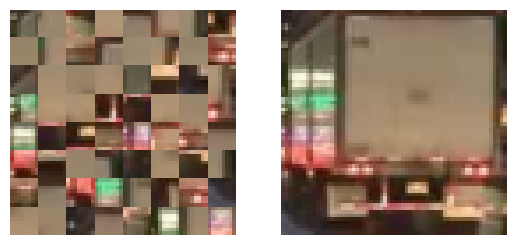

In [22]:
### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###
vis_dataset_noisy = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor(), PatchShuffle(patch_size=8)]),
)
vis_dataset_clean = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor()]),
)
fig, ax = plt.subplots(1, 2)
img_noisy, label = vis_dataset_noisy[16]
img_clean, label = vis_dataset_clean[16]
ax[0].imshow(TF.to_pil_image(img_noisy))
ax[1].imshow(TF.to_pil_image(img_clean))
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
    a.set_frame_on(False)
### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###

### Implementation

In [23]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, emb_dim, num_heads, mlp_ratio=4):
        super().__init__()
        self.attention = nn.MultiheadAttention(emb_dim, num_heads, batch_first=True)
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim, emb_dim * mlp_ratio),
            nn.ReLU(),
            nn.Linear(emb_dim * mlp_ratio, emb_dim),
        )
        self.norm1 = nn.LayerNorm(emb_dim)
        self.norm2 = nn.LayerNorm(emb_dim)

    def forward(self, x):
        x = x + self.attention(x, x, x)[0]  # self.attention returns (output, weights)
        x = self.norm1(x)
        x = x + self.mlp(x)
        x = self.norm2(x)
        return x


class Task2ViT(nn.Module):
    def __init__(
        self,
        patch_size=8,
        in_channels=3,
        num_classes=8,
        embed_dim=128,
        num_blocks=4,
        num_heads=4,
        mlp_dim=4,
    ):
        super().__init__()
        self.patch_embed = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size,
        )
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.blocks = nn.ModuleList(
            [
                TransformerEncoderBlock(embed_dim, num_heads, mlp_dim)
                for _ in range(num_blocks)
            ]
        )
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)  # (B, Seq_Len, Embed_Dim)
        batch_size = x.size(0)

        cls_token = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        for block in self.blocks:
            x = block(x)
        # Use the classification token output for classification
        return self.head(x[:, 0])


class Task2LitModule(pl.LightningModule):
    def __init__(self, num_classes=8):
        super().__init__()
        self.model = Task2ViT(num_classes=num_classes)
        self.loss_fn = nn.CrossEntropyLoss()
        self.history = {"train_loss": [], "eval_loss": []}

        self.test_precision = MulticlassPrecision(num_classes=num_classes, average=None)
        self.test_recall = MulticlassRecall(num_classes=num_classes, average=None)

    def on_train_start(self):
        self.history = {"train_loss": [], "eval_loss": []}

    def forward(self, x):
        return self.model(x)

    def predict_step(self, images):
        logits = self(images)
        return logits.argmax(dim=1)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        logits = self(images)
        loss = self.loss_fn(logits, labels)
        self.log(
            "train_loss",
            loss,
            on_step=True,
            on_epoch=True,
            prog_bar=True,
            batch_size=images.size(0),
        )
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        logits = self(images)
        loss = self.loss_fn(logits, labels)
        self.log(
            "eval_loss",
            loss,
            on_step=True,
            on_epoch=True,
            prog_bar=True,
            batch_size=images.size(0),
        )
        return loss

    def on_train_epoch_end(self):
        avg_loss = self.trainer.callback_metrics["train_loss_epoch"].item()
        self.history["train_loss"].append(avg_loss)

    def on_validation_epoch_end(self):
        avg_loss = self.trainer.callback_metrics["eval_loss_epoch"].item()
        self.history["eval_loss"].append(avg_loss)

    def on_test_epoch_start(self):
        self.test_precision.reset()
        self.test_recall.reset()

    def test_step(self, batch, batch_idx):
        images, labels = batch
        predictions = self.predict_step(images)

        self.test_precision(predictions, labels)
        self.test_recall(predictions, labels)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=3e-4, weight_decay=1e-2)

### Training

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name           | Type                | Params | Mode  | FLOPs
-----------------------------------------------------------------------
0 | model          | Task2ViT            | 818 K  | train | 0    
1 | loss_fn        | CrossEntropyLoss    | 0      | train | 0    
2 | test_precision | MulticlassPrecision | 0      | train | 0    
3 | test_recall    | MulticlassRecall    | 0      | train | 0    
-----------------------------------------------------------------------
818 K     T

`Trainer.fit` stopped: `max_epochs=10` reached.


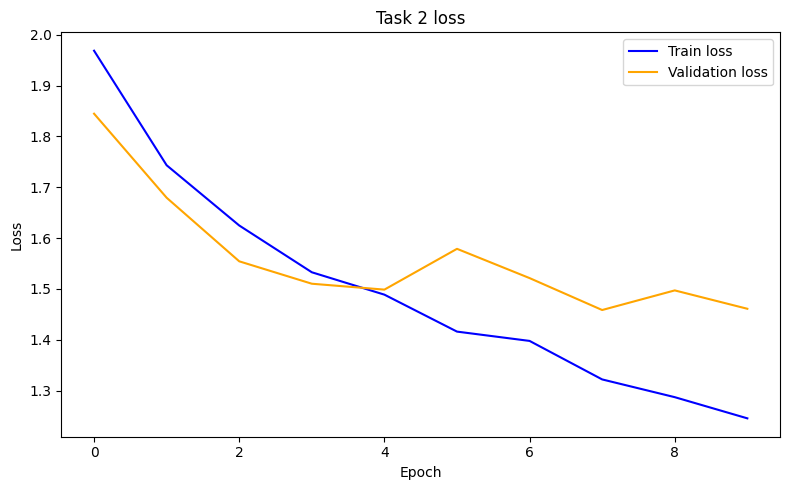

In [24]:
# train
train_loader = DataLoader(train_camera_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(noisy_test_camera_dataset, batch_size=32, shuffle=False)

task2_lit_module = Task2LitModule()
trainer = pl.Trainer(
    max_epochs=10,
    accelerator="auto",
    fast_dev_run=FAST_DEV_RUN,
)
trainer.fit(
    task2_lit_module, train_dataloaders=train_loader, val_dataloaders=test_loader
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(task2_lit_module.history["train_loss"], label="Train loss", color="blue")
ax.plot(task2_lit_module.history["eval_loss"], label="Validation loss", color="orange")
ax.set_title("Task 2 loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.tight_layout()
plt.show()

### Evaluation
Compute the same two evaluation metrics introduced in Task 1, for each object class individually.

First visualize the per-class metrics in a single figure. Then aggregate the per-class metrics across all classes on the corrupted test set. Finally reevaluate the model on the clean test set without the PatchShuffle corruption transformation and report the resulting aggregated metrics for both test sets (4 scalar values).

As a baseline requirement, your model must achieve a score of at least 0.3 on both aggregated evaluation metrics on the noisy test set.

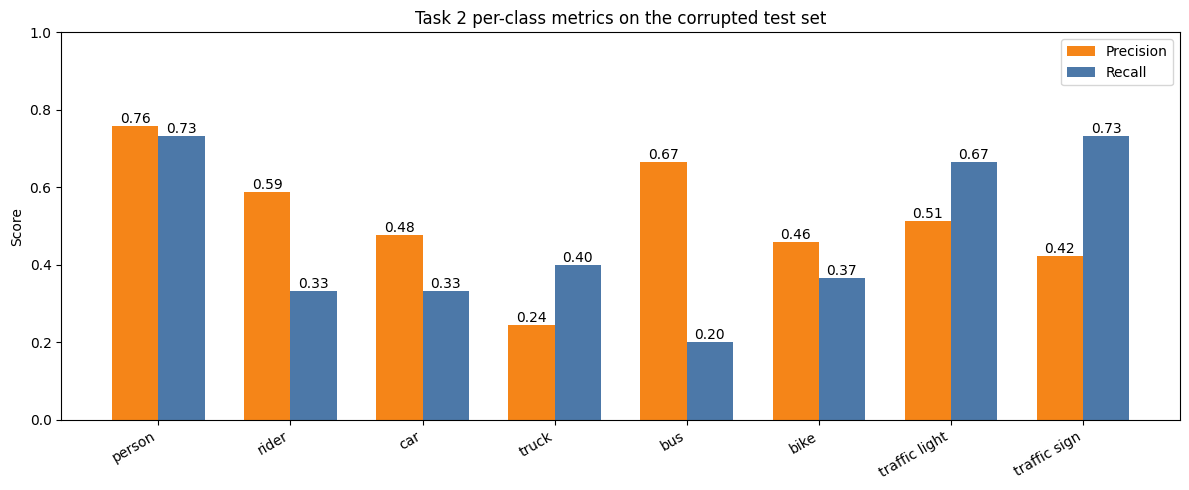

Noisy test precision: 0.5161
Noisy test recall: 0.4708
Clean test precision: 0.5161
Clean test recall: 0.4708


In [25]:
num_classes = len(train_camera_dataset.class_to_id)
class_names = [train_camera_dataset.id_to_class[i] for i in range(num_classes)]

# test on clean dataset
clean_test_loader = DataLoader(clean_test_camera_dataset, batch_size=32, shuffle=False)
noisy_test_loader = DataLoader(noisy_test_camera_dataset, batch_size=32, shuffle=False)

trainer.test(task2_lit_module, dataloaders=clean_test_loader)

clean_precision = task2_lit_module.test_precision.compute().cpu()
clean_recall = task2_lit_module.test_recall.compute().cpu()

# test on noisy dataset
trainer.test(task2_lit_module, dataloaders=noisy_test_loader)

noisy_precision = task2_lit_module.test_precision.compute().cpu()
noisy_recall = task2_lit_module.test_recall.compute().cpu()

# bar plot
x = np.arange(num_classes)
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
rects1 = ax.bar(
    x - width / 2, noisy_precision.numpy(), width, label="Precision", color="#f58518"
)
rects2 = ax.bar(
    x + width / 2, noisy_recall.numpy(), width, label="Recall", color="#4c78a8"
)
ax.bar_label(rects1, fmt="%.2f")
ax.bar_label(rects2, fmt="%.2f")
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Task 2 per-class metrics on the corrupted test set")
ax.legend()
plt.tight_layout()
plt.show()

noisy_precision_mean = noisy_precision.mean().item()
noisy_recall_mean = noisy_recall.mean().item()
task2_clean_precision_mean = clean_precision.mean().item()
task2_clean_recall_mean = clean_recall.mean().item()

print(f"Noisy test precision: {noisy_precision_mean:.4f}")
print(f"Noisy test recall: {noisy_recall_mean:.4f}")
print(f"Clean test precision: {task2_clean_precision_mean:.4f}")
print(f"Clean test recall: {task2_clean_recall_mean:.4f}")

### Aggregate metrics Table for the clean/corrupted test set
Report the aggregate metrics for the clean/corrupted test set. Your table must be 2x2 where each row corresponds to a metric and each column to a dataset.

In [26]:
aggregate_metrics = pd.DataFrame(
    {
        "Clean test set": [
            task2_clean_precision_mean,
            task2_clean_recall_mean,
        ],
        "Noisy test set": [
            noisy_precision_mean,
            noisy_recall_mean,
        ],
    },
    index=["Precision", "Recall"],
)

aggregate_metrics

,Clean test set,Noisy test set
Precision,0.516105,0.516105
Recall,0.470833,0.470833


## Task 3 

In this final task, you are asked to evaluate whether a general-purpose pretrained vision model
can produce useful feature representations for object classification on the object classification
dataset BDDObjectClassificationDataset .
Unlike Task 2, where robustness to the PatchShuffle sensor corruption process was explicitly
investigated, this task considers a future hardware revision in which the sensor corruption issue
has been resolved. Consequently, all experiments in this task must be performed using the
standard uncorrupted version of the dataset.

You must employ a pretrained model of your choice belonging to the same architecture family
as the model developed in Task 2. The pretrained encoder must be used as a frozen feature
extractor, meaning that its pretrained parameters are kept fixed and are not updated during
training.

### Feature extractor
Extract feature representations for all training and test images using the frozen pretrained encoder.

In [27]:
# use the pretrained ViT-B/16 available in torchvision and remove the classification head
weights = ViT_B_16_Weights.IMAGENET1K_V1
preprocess = Compose(
    [
        BottomRightSquarePad(),
        weights.transforms(),
    ]
)

train_feature_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="train",
    img_transform=preprocess,
)
test_feature_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=preprocess,
)

train_feature_loader = DataLoader(train_feature_dataset, batch_size=32, shuffle=False)
test_feature_loader = DataLoader(test_feature_dataset, batch_size=32, shuffle=False)

feature_extractor = vit_b_16(weights=weights)
feature_extractor.heads = nn.Identity()
feature_extractor = feature_extractor.to(DEVICE)
feature_extractor.eval()
for parameter in feature_extractor.parameters():
    parameter.requires_grad = False


def extract_features(model, loader):
    features, labels = [], []

    with torch.no_grad():
        for images, batch_labels in loader:
            images = images.to(DEVICE)
            batch_features = model(images)
            features.append(batch_features.cpu())
            labels.append(batch_labels.cpu())

    return torch.cat(features, dim=0), torch.cat(labels, dim=0)


task3_train_features, task3_train_labels = extract_features(
    feature_extractor, train_feature_loader
)
test_features, test_labels = extract_features(feature_extractor, test_feature_loader)

print(f"Train features shape: {task3_train_features.shape}")
print(f"Test features shape: {test_features.shape}")

Train features shape: torch.Size([2400, 768])
Test features shape: torch.Size([240, 768])


### Linear probing
Perform linear probing by training a learnable linear classifier on top of the frozen pretrained model representations.

Since pretrained models can be computationally expensive, the linear classifier does not need to be trained for more than 10 epochs.

In [28]:
train_feature_dataset = TensorDataset(task3_train_features, task3_train_labels)
test_feature_dataset = TensorDataset(test_features, test_labels)

train_feature_loader = DataLoader(train_feature_dataset, batch_size=32, shuffle=True)
test_feature_loader = DataLoader(test_feature_dataset, batch_size=32, shuffle=False)


class Task3LinearProbe(pl.LightningModule):
    def __init__(self, feature_dim, num_classes):
        super().__init__()
        self.classifier = nn.Linear(feature_dim, num_classes)
        self.loss_fn = nn.CrossEntropyLoss()

        self.test_precision = MulticlassPrecision(num_classes=num_classes, average=None)
        self.test_recall = MulticlassRecall(num_classes=num_classes, average=None)

    def forward(self, x):
        return self.classifier(x)

    def predict_step(self, images):
        logits = self(images)
        return logits.argmax(dim=1)

    def training_step(self, batch, batch_idx):
        features, labels = batch
        logits = self(features)
        loss = self.loss_fn(logits, labels)
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        features, labels = batch
        logits = self(features)
        loss = self.loss_fn(logits, labels)
        self.log("eval_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def on_test_epoch_start(self):
        self.test_precision.reset()
        self.test_recall.reset()

    def test_step(self, batch, batch_idx):
        images, labels = batch
        predictions = self.predict_step(images)

        self.test_precision(predictions, labels)
        self.test_recall(predictions, labels)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters())


task3_lit_module = Task3LinearProbe(task3_train_features.shape[1], num_classes)
trainer = pl.Trainer(
    max_epochs=10,
    accelerator="auto",
    fast_dev_run=FAST_DEV_RUN,
)
trainer.fit(
    task3_lit_module,
    train_dataloaders=train_feature_loader,
    val_dataloaders=test_feature_loader,
)

trainer.test(task3_lit_module, dataloaders=test_feature_loader)

task3_linear_precision = task3_lit_module.test_precision.compute().cpu()
task3_linear_recall = task3_lit_module.test_recall.compute().cpu()

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name           | Type                | Params | Mode  | FLOPs
-----------------------------------------------------------------------
0 | classifier     | Linear              | 6.2 K  | train | 0    
1 | loss_fn        | CrossEntropyLoss    | 0      | train | 0    
2 | test_precision | MulticlassPrecision | 0      | train | 0    
3 | test_recall    | MulticlassRecall    | 0      | train | 0    
-----------------------------------------------------------------------
6.2 K     T

`Trainer.fit` stopped: `max_epochs=10` reached.
/Users/mirco/Developer/DL-HWs/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


### kNN
Perform k-nearest neighbor (kNN) classification directly in the pretrained model representations using a single value of k.

In [29]:
def predict_knn(train_features, train_labels, query_features, k=3):
    normalized_train_features = F.normalize(train_features, dim=1)
    normalized_query_features = F.normalize(query_features, dim=1)
    # compute similarities
    similarities = normalized_query_features @ normalized_train_features.T
    # given query sample, filter top-k support samples
    neighbor_indices = similarities.topk(k, dim=1).indices
    neighbor_labels = train_labels[neighbor_indices]
    num_classes = int(train_labels.max().item()) + 1
    # count votes
    votes = F.one_hot(neighbor_labels, num_classes=num_classes).sum(dim=1)
    return votes.argmax(dim=1)


task3_knn_predictions = predict_knn(
    task3_train_features, task3_train_labels, test_features, k=3
)

task3_knn_precision = multiclass_precision(
    task3_knn_predictions, test_labels, num_classes=num_classes
)
task3_knn_recall = multiclass_recall(
    task3_knn_predictions, test_labels, num_classes=num_classes
)

### Evaluation

Compare and visualize the resulting comparison in a single figure the performance of:
- the pretrained model with linear probing,
- the pretrained model with kNN classification,
- and the model trained from scratch in Task 2 using the previously introduced aggregated test metrics,

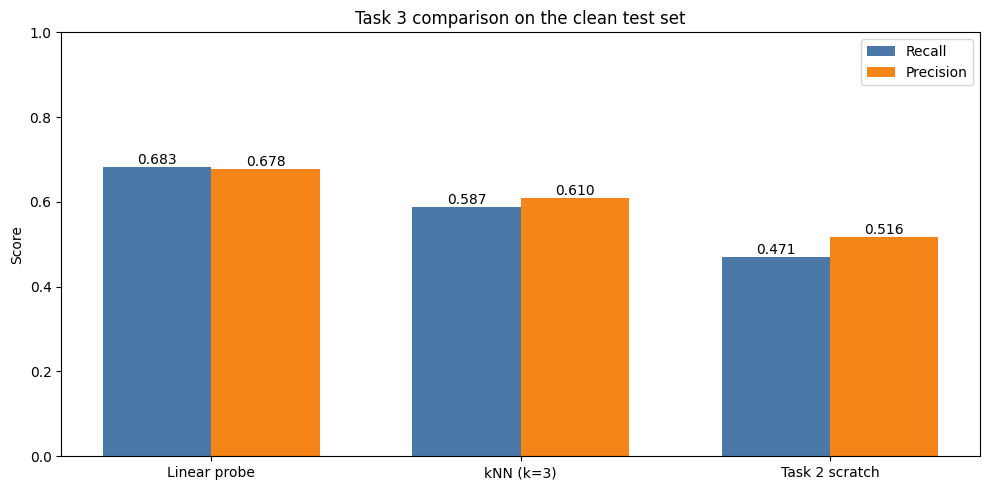

In [30]:
task3_knn_precision_mean = task3_knn_precision.mean().item()
task3_knn_recall_mean = task3_knn_recall.mean().item()

task3_linear_precision_mean = task3_linear_precision.mean().item()
task3_linear_recall_mean = task3_linear_recall.mean().item()

comparison_labels = ["Linear probe", "kNN (k=3)", "Task 2 scratch"]
precision_values = [
    task3_linear_precision_mean,
    task3_knn_precision_mean,
    task2_clean_precision_mean,
]
recall_values = [
    task3_linear_recall_mean,
    task3_knn_recall_mean,
    task2_clean_recall_mean,
]

x = np.arange(len(comparison_labels))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - width / 2, recall_values, width, label="Recall", color="#4c78a8")
rects2 = ax.bar(
    x + width / 2, precision_values, width, label="Precision", color="#f58518"
)
ax.set_xticks(x)
ax.set_xticklabels(comparison_labels)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Task 3 comparison on the clean test set")
ax.bar_label(rects1, fmt="%.3f")
ax.bar_label(rects2, fmt="%.3f")
ax.legend()
plt.tight_layout()
plt.show()